# Netrunner Agenda Density Analysis

In [1]:
# Imports

import pandas as pd
import main as m
import regex as re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')


Left adjust Markdown tables

In [2]:
%%html
<style>
    table {
        margin-left: 0 !important;
        float: left;
    }
</style>

## Wrangle

In [3]:
df = pd.read_excel('accesses.xlsx')

df['overall_agenda_density'] = (df['agenda_points'] - df['let_them_dream_count']) / df['deck_size']

df_normal = df[df.agenda_type == 'Normal']
df_ltd = df[(df.agenda_type == 'Let Them Dream') & (df.let_them_dream_count > 0)]

In [4]:
len(df_normal)

496

In [5]:
len(df_ltd)

432

In Netrunner a corporation deck must contain a total number of cards (deck size) and agenda points according to the following chart

This Dataset represents all possible variations of corporation decks with regard to max/min deck dize, agenda point total, and distribution of one, two, and three point agenda cards and inclution of 'Let them Dream' agendas. This data set was generated using values found in the standard card pool as of (April 21, 2026).

|Deck Size|Agenda Points|
|---|---|
|40 to 44 | 18 or 19 |
|45 to 49 | 20 or 21 |
|50 to 54 | 22 or 23 |

<br>
<br>
<br>
<br>
<br>

## Data Dictionary

|Feature|Definition|
|---|---|
|Agenda Type| "Normal" indicates that there are no Let Them Dream Agendas in the deck "Let Them Dream" indicates that the maximum number of two-point agendas are "Let Them Dream"|
|Deck Size| Count of cards in the deck|
|Agenda Points| Total agenda points used in the deck|
|Agenda Counts| Count of each agenda in the deck by point value \[three-point agendas, two-point agendas, one-point agendas\]|
|Let Them Dream Count| Count of "Let Them Dream" cards in the deck|
|Num Agendas| Count of agendas in deck|
|Average Accesses| Number of unique cards a runner must access, on average, to win the game|

<br>
<br>

**Let them Dream** is an agenda worth two points for the corp, but only one point for the runner

* This card counts as a two point agenda when counting the total Agenda Points in a corporation deck
* This card is represented as a one-point agenda in Agenda Counts and when determining Average Accesses

**Average Accesses** was determined using digital experiments

* Method
    * Generate list representing agenda values of each card in the corporation's deck using zero to represent non-agenda cards
    * Choose a 'card' from the list at random for the runner to 'access'
    * Add the the value of the 'accessed' card to the runners total and remove the card from the list
    * Continue choosing new 'cards' until the runner has accessed 7 points worth of cards and note the number of accesses
    * Repeat the experiment 100_000 times and calculate the average number of accesses across all of the experiments


## Exploration

### Initial Inspection

**Data types are as expected**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   agenda_type             992 non-null    object 
 1   deck_size               992 non-null    int64  
 2   agenda_points           992 non-null    int64  
 3   let_them_dream_count    992 non-null    int64  
 4   agenda_counts           992 non-null    object 
 5   num_agendas             992 non-null    int64  
 6   average_accesses        992 non-null    int64  
 7   overall_agenda_density  992 non-null    float64
dtypes: float64(1), int64(5), object(2)
memory usage: 62.1+ KB


**Deck sizes and agenda point totals are matched to reflect deckbuilding requirements**

In [7]:
deck_sizes = [40, 44, 45, 49, 50, 54]

for deck_size in deck_sizes:

    print(df[['deck_size', 'agenda_points']][df.deck_size == deck_size].drop_duplicates())

    deck_size  agenda_points
0          40             18
70         40             19
     deck_size  agenda_points
144         44             18
214         44             19
     deck_size  agenda_points
288         45             20
368         45             21
     deck_size  agenda_points
454         49             20
534         49             21
     deck_size  agenda_points
620         50             22
710         50             23
     deck_size  agenda_points
806         54             22
896         54             23


**Agenda counts are accurate**

In [8]:
# code for testing agenda point accuracy

# get number of one, two, and three point agendas in separate columns
df['threes'] = df.agenda_counts.apply(lambda x: int(re.search('\[(\d+),', x).group(1)))
df['twos'] = df.agenda_counts.apply(lambda x: int(re.search(', (\d+),', x).group(1)))
df['ones'] = df.agenda_counts.apply(lambda x: int(re.search(', (\d+)\]', x).group(1)))

# calculate total agenda points including points 'removed from Let Them Dream agendas
df['calc_agenda_points'] = (df['threes'] * 3) + (df['twos'] * 2) + (df['ones']) + (df['let_them_dream_count'])

# show dataframe of all rows that do not have matching calculated and expectd agenda point totals
df[df.calc_agenda_points != df.agenda_points]

,agenda_type,deck_size,agenda_points,let_them_dream_count,agenda_counts,num_agendas,average_accesses,overall_agenda_density,threes,twos,ones,calc_agenda_points


### Average Accesses Overview

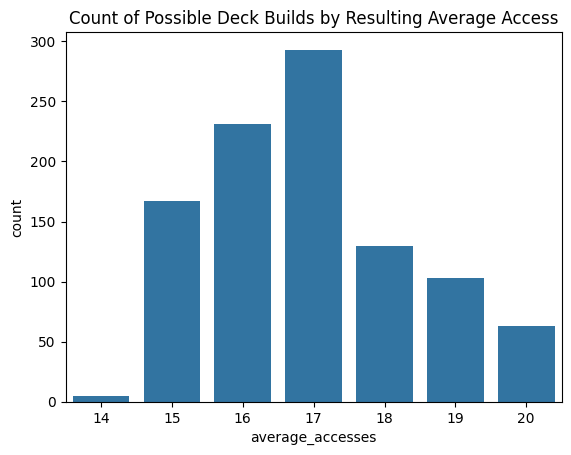

In [9]:
ax = sns.countplot(x='average_accesses',data=df).set_title('Count of Possible Deck Builds by Resulting Average Access')

* Most possible builds require 17 unique accesses on average for the the runner to win
* Possible build numbers drop of dramatically as average required accesses moves away from 17 in either direction
* The range of average required accesses is from 14 - 20 so agenda density and concentration account for up to 6 additional/fewer average required accesses

## Agenda Density
* Denifed as the total number of agenda points the runner is able to steal in a corp deck devided by the total number of cards in the corp deck

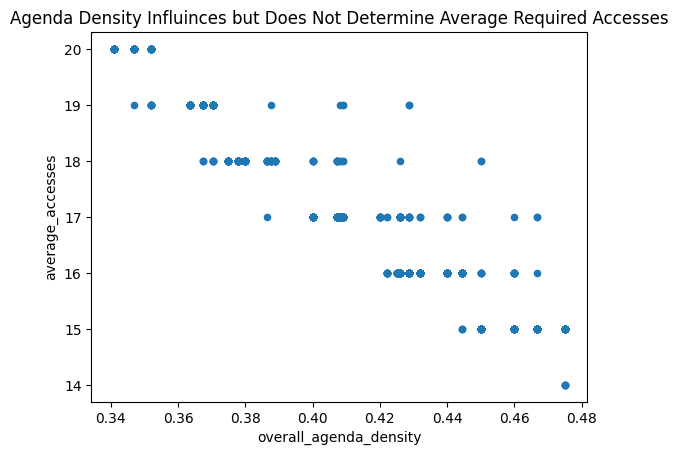

In [10]:
df.plot.scatter(x='overall_agenda_density', y='average_accesses', title='Agenda Density Influinces but Does Not Determine Average Required Accesses')
plt.show()

* There is an inverse relationship between agenda density and average required accesses
* The range between the smallest and largest available agenda density is
* Decks with the same resulting average required accesses can have a range of agenda densities that are cover 60-75% of the total range for the distribution
* Decks with the same or similar agenda density can have as many as 4 different average required access
* Agenda density has a more pronounced effect at exteam high or low values                                                

# Deck Size

* The required number of agenda points begins at 18 for a minimum 40 card deck this increases by 2 for every five cards added after that
* Because the added cards have a lower agenda density than the original minimum corps can lower there agenda density by incresing thier deck size
* Because each minimum deck size has a '4 card mirgin' untill the next manditory agenda point increas it is common wisdom to add an extra 4 cards to the minimum when building a deck to decrese agenda density

**Effect of Overall Deck Size**

* Corporations have a starting deck size of 40, 45, or 50 depending on which identity they choose



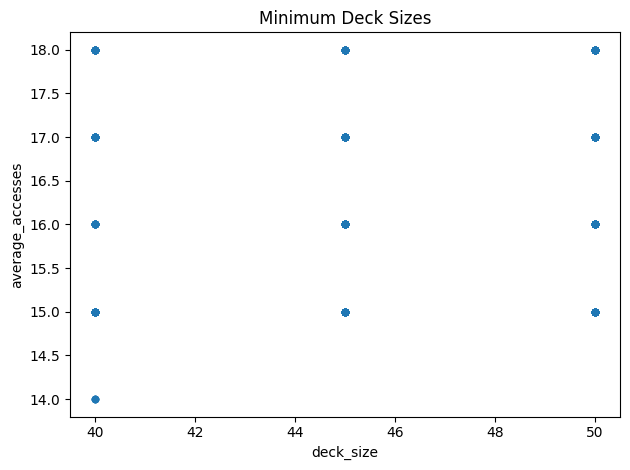

In [11]:
df_min = df[df.deck_size.isin([40,45,50])]

df_min.plot.scatter(x='deck_size', y='average_accesses', title='Minimum Deck Sizes')

plt.tight_layout()
plt.show()

* The effect of deck size on average required accesses is negligible

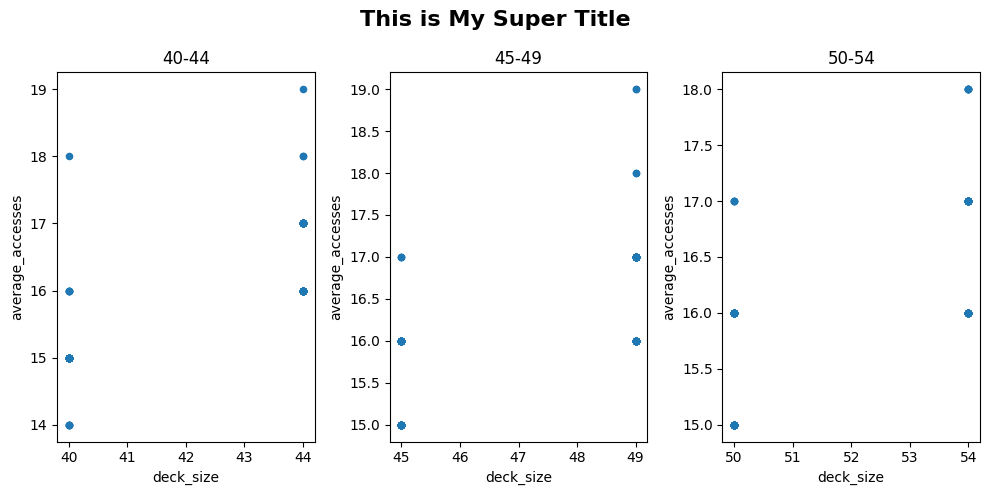

In [13]:
df_normal_small = df_normal[df['deck_size'].between(40,44)]
df_normal_mid = df_normal[df.deck_size.between(45,49)]
df_normal_lg = df_normal[df.deck_size.between(50,54)]

fig, axes = plt.subplots(ncols=3, figsize=(10,5), constrained_layout=True)
df_normal_small.plot.scatter(x='deck_size', y='average_accesses', title='40-44', ax=axes[0])
df_normal_mid.plot.scatter(x='deck_size', y='average_accesses', title='45-49', ax=axes[1])
df_normal_lg.plot.scatter(x='deck_size', y='average_accesses', title='50-54', ax=axes[2])

fig.suptitle('This is My Super Title', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

* The distribution of average accesses shifts up by 1-2 when the four card margin is used 
* This suggests that the average required accesses will increse by one to two accesses when the for card margin is used

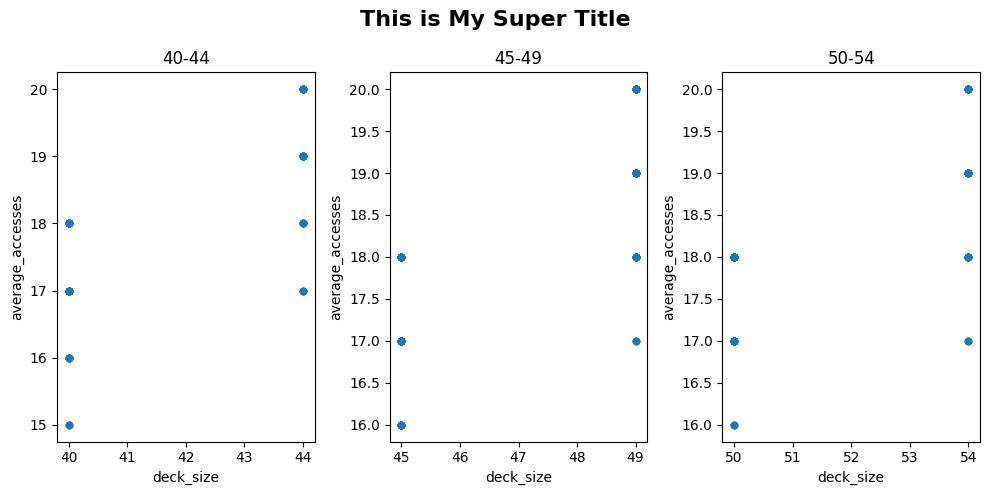

In [15]:
df_ltd_small = df_ltd[df['deck_size'].between(40,44)]
df_ltd_mid = df_ltd[df.deck_size.between(45,49)]
df_ltd_lg = df_ltd[df.deck_size.between(50,54)]

fig, axes = plt.subplots(ncols=3, figsize=(10,5), constrained_layout=True)
df_ltd_small.plot.scatter(x='deck_size', y='average_accesses', title='40-44', ax=axes[0])
df_ltd_mid.plot.scatter(x='deck_size', y='average_accesses', title='45-49', ax=axes[1])
df_ltd_lg.plot.scatter(x='deck_size', y='average_accesses', title='50-54', ax=axes[2])

fig.suptitle('This is My Super Title', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

* The effect is even more pronounced when using let them dream suggesting an increase of 2 average required access 

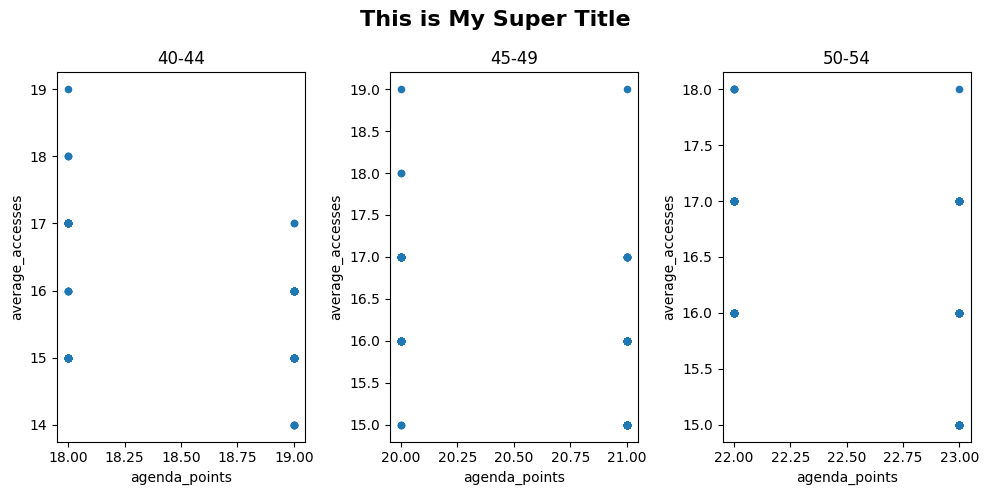

In [23]:
df_normal_small = df_normal[(df_normal.deck_size.between(40,44)) & (df_normal.agenda_points.isin([18,19]))]
df_normal_mid = df_normal[(df_normal.deck_size.between(45,49)) & (df_normal.agenda_points.isin([20,21]))]
df_normal_lg = df_normal[(df_normal.deck_size.between(50,54)) & (df_normal.agenda_points.isin([22,23]))]

fig, axes = plt.subplots(ncols=3, figsize=(10,5), constrained_layout=True)
df_normal_small.plot.scatter(x='agenda_points', y='average_accesses', title='40-44', ax=axes[0])
df_normal_mid.plot.scatter(x='agenda_points', y='average_accesses', title='45-49', ax=axes[1])
df_normal_lg.plot.scatter(x='agenda_points', y='average_accesses', title='50-54', ax=axes[2])

fig.suptitle('This is My Super Title', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
def plot_grid_by_list(df, values, filter_col, x_col, y_col,
                      ncols=4, nrows=2, figsize=(16,8), marker='o', s=20):
    """
    df: pandas DataFrame
    values: list of values to iterate through (one value per subplot)
    filter_col: column name to filter df by equality to each value
    x_col, y_col: columns to plot
    ncols, nrows: grid shape (default 4x2)
    """
    total = ncols * nrows
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=False, sharey=False)
    axes = axes.flatten()

    for i in range(total):
        ax = axes[i]
        if i < len(values):
            val = values[i]
            sub = df[df[filter_col] == val]
            if not sub.empty:
                sub.plot.scatter(x=x_col, y=y_col, ax=ax, title=f"{filter_col}={val}", marker=marker, s=s)
            else:
                ax.set_title(f"{filter_col}={val} (no data)")
                ax.set_xticks([])
                ax.set_yticks([])
        else:
            # blank any unused subplots
            ax.axis('off')

    plt.tight_layout()
    plt.show()


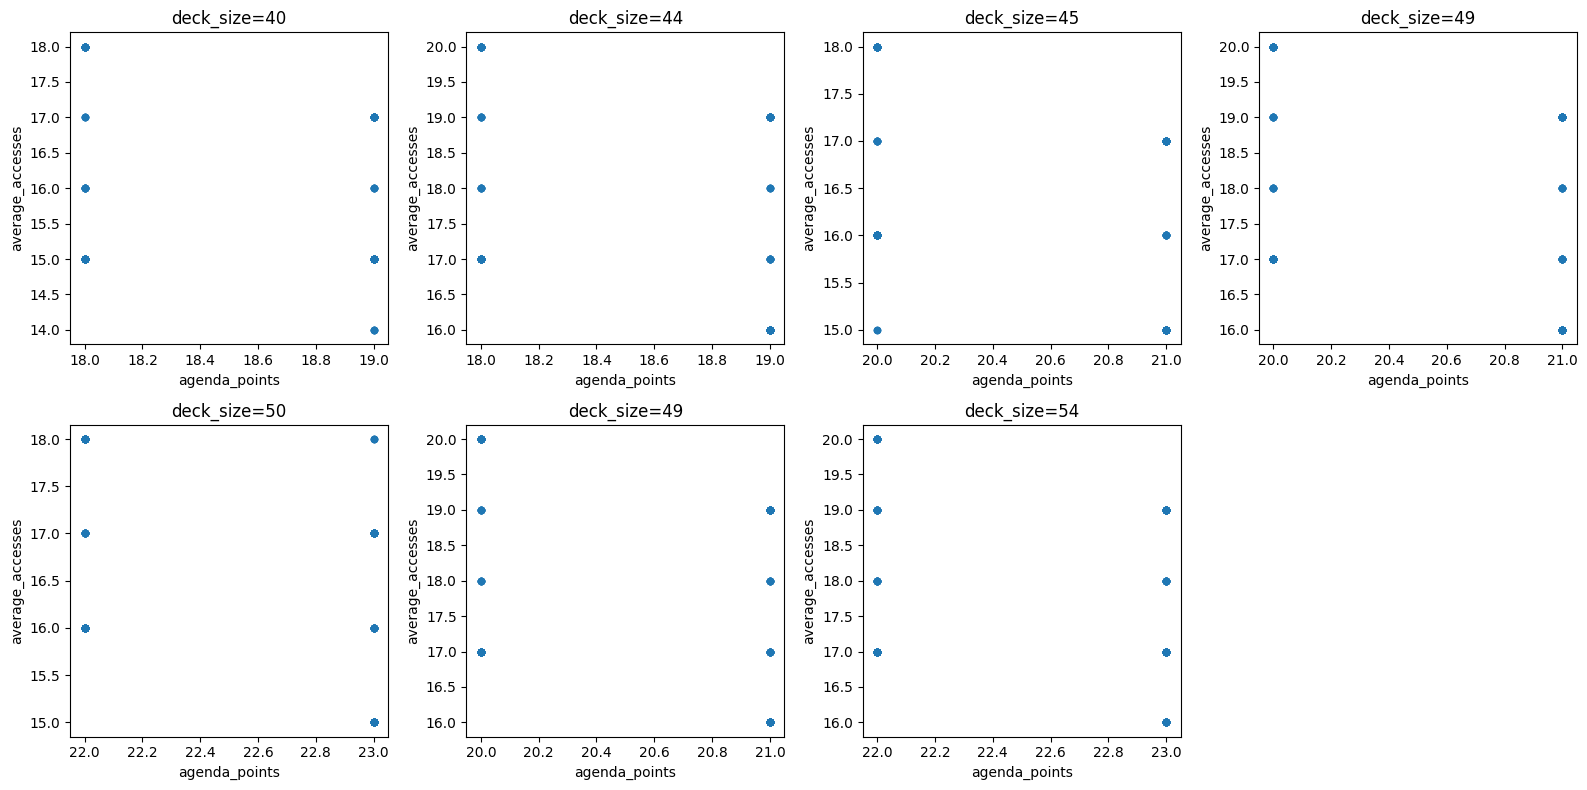

In [20]:
plot_grid_by_list(df, [40,44,45,49,50,49,54], 'deck_size', 'agenda_points', 'average_accesses',
                      ncols=4, nrows=2, figsize=(16,8), marker='o', s=20)

* movement of distribution indicates that one additional access is needed if the higher agenda point total is used

In [ ]:
# Agenda Concentration

In [ ]:
df_normal.plot.scatter(x='deck_size', y='average_accesses', title='title')
plt.show()

In [ ]:
df_ltd.plot.scatter(x='deck_size', y='average_accesses', title='title')
plt.show()

In [ ]:
norm = df[['deck_size', 'agenda_points', 'overall_agenda_density', 'average_accesses']][df['agenda_type'] == 'Normal'].drop_duplicates().sort_values(by='overall_agenda_density')
norm

In [ ]:
dream = df[['deck_size', 'agenda_points', 'overall_agenda_density', 'average_accesses']][df['agenda_type'] == 'Let Them Dream'].drop_duplicates().sort_values(by='agenda_density')
dream

In [ ]:
dream.describe()

In [ ]:
df_den = df[['agenda_type', 'deck_size', 'let_them_dream_count', 'agenda_points', 'overall_agenda_density', 'average_accesses']].drop_duplicates()

In [ ]:
df_den[df.agenda_type == 'Normal'].drop(columns = ['let_them_dream_count']).sort_values(by='overall_agenda_density')

In [ ]:
/df['twos'] = df.agenda_counts.apply(lambda x: re.search(',(\d+),', x))
df['ones'] = df.agenda_counts.apply(lambda x: re.search(',(\d+)\]', x))
df

In [ ]:
df['calc_agenda_points'] = df['threes'] * 3 + df['twos'] * 2 + df['ones'] + df['let_them_dream_count']

df.calc_agenda_totals == df.agenda_points

In [ ]:
df[(df['agenda_type'] == "Normal") & (df['deck_size'] == 40) & (df['average_accesses'] != 15)].head(50)